# 01 EDA

Use this notebook only for data understanding: summary statistics, skew, outliers, target cap analysis, and feature-target relationships.

In [52]:
import os
import sys
from pathlib import Path

sys.path.append(os.path.abspath('..'))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [53]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
feature_df = pd.read_csv(Path('../data/processed/california_housing_features.csv'))

In [54]:
feature_df.describe().T

,count,mean,std,min,25%,50%,75%,max
median_income,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
house_age,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
average_rooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
average_bedrooms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
average_occupancy,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
median_house_value,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010
bedroom_ratio,20640.0,0.213075,0.058023,0.100000,0.175426,0.203181,0.239834,1.000000


In [55]:
feature_df.isna().sum().sort_values(ascending=False)

median_income               0
log_population              0
log_rooms_per_person        0
average_bedrooms_capped     0
log_average_bedrooms        0
average_rooms_capped        0
log_average_rooms           0
average_occupancy_capped    0
log_average_occupancy       0
population_capped           0
rooms_per_person            0
house_age                   0
bedroom_ratio               0
median_house_value          0
longitude                   0
latitude                    0
average_occupancy           0
population                  0
average_bedrooms            0
average_rooms               0
rooms_per_person_capped     0
dtype: int64

In [56]:
feature_df.skew(numeric_only=True).sort_values(ascending=False).to_frame('skew')

,skew
average_occupancy,97.639561
average_bedrooms,31.316956
average_rooms,20.697869
rooms_per_person,17.775133
log_average_bedrooms,8.988786
population,4.935858
average_bedrooms_capped,4.021616
log_average_occupancy,3.879679
bedroom_ratio,2.246891
population_capped,1.952252


In [57]:
feature_df.corr(numeric_only=True)['median_house_value'].sort_values(ascending=False).to_frame('target_correlation')

,target_correlation
median_house_value,1.000000
median_income,0.688075
rooms_per_person_capped,0.394224
log_rooms_per_person,0.353401
average_rooms_capped,0.293026
log_average_rooms,0.241034
rooms_per_person,0.209482
average_rooms,0.151948
house_age,0.105623
log_population,-0.021205


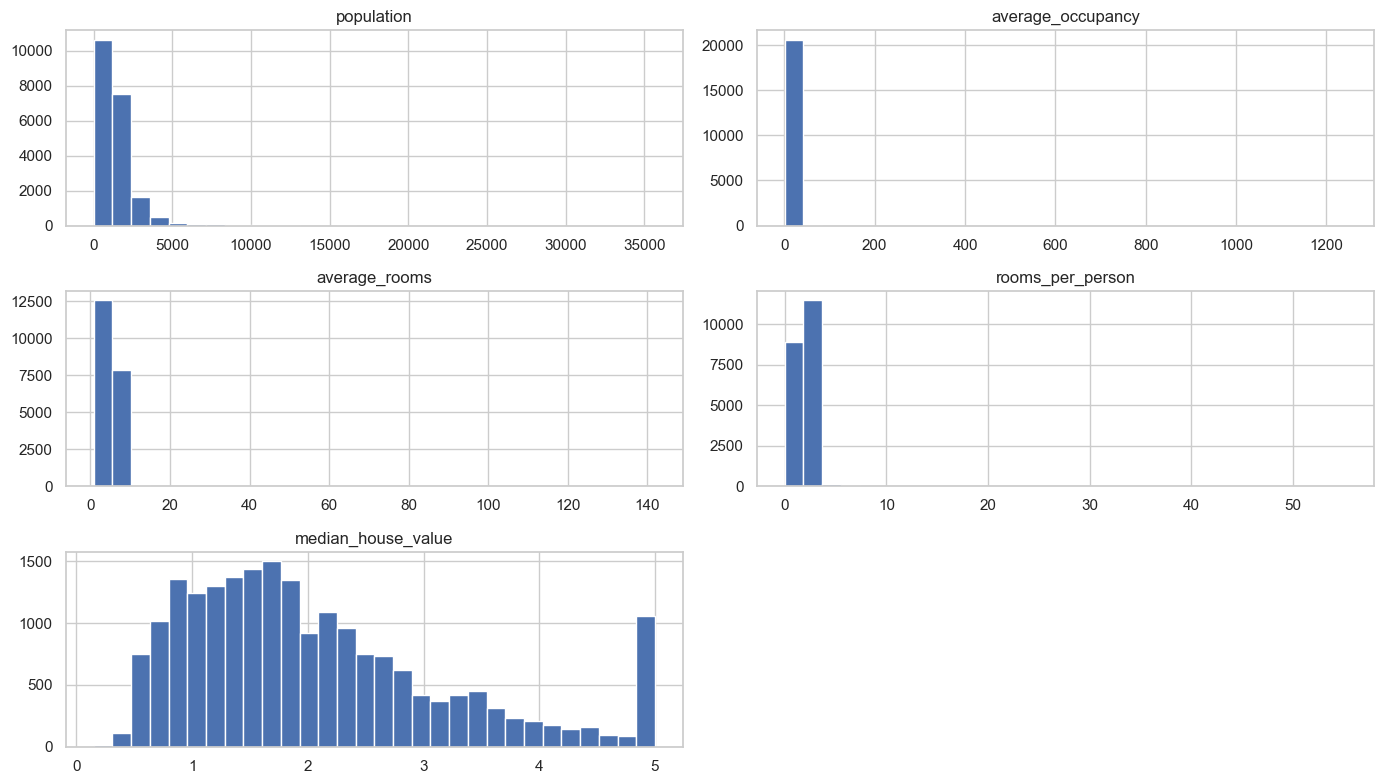

In [58]:
columns_to_plot = ['population', 'average_occupancy', 'average_rooms', 'rooms_per_person', 'median_house_value']
feature_df[columns_to_plot].hist(bins=30, figsize=(14, 8))
plt.tight_layout()

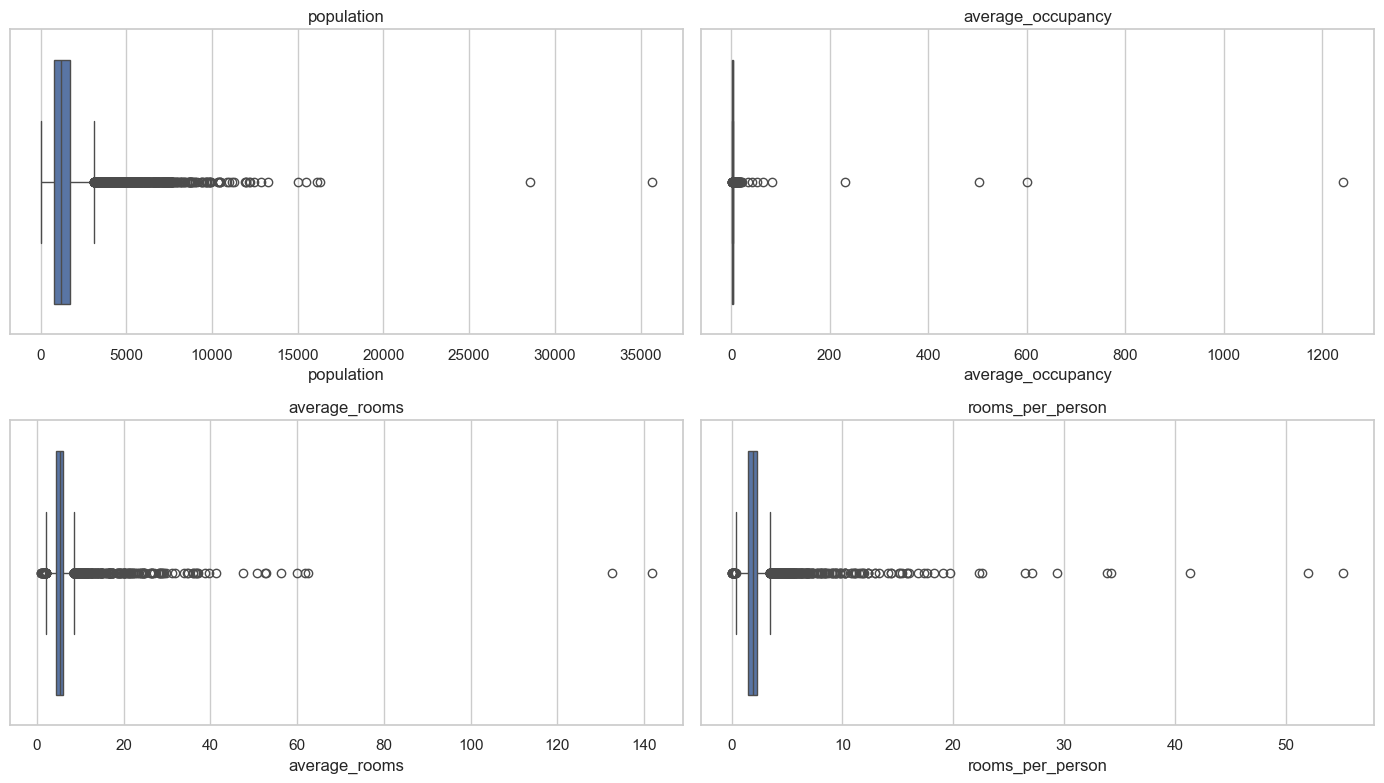

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_columns = ['population', 'average_occupancy', 'average_rooms', 'rooms_per_person']
for axis, column in zip(axes.flatten(), plot_columns):
    sns.boxplot(x=feature_df[column], ax=axis)
    axis.set_title(column)
plt.tight_layout()